# 07 — Comparação consolidada

Fecha o ciclo: lê os cartões gravados por todos os notebooks anteriores e monta a tabela que a
plataforma exibe em **Modelos de Machine Learning**. Nenhum número é digitado aqui — todos vêm
de `ml/models/*.json`, que por sua vez foram escritos pelo treino.

In [1]:
import sys, warnings
from pathlib import Path

warnings.filterwarnings('ignore')
RAIZ = Path.cwd().parents[1] if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 160)
pd.set_option('display.max_columns', 40)
plt.rcParams['figure.figsize'] = (11, 4)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

from ml.src import config, dataset, explain, features, metrics, models_zoo, registry, selecao, splits, train
print('Banco:', config.BANCO, '| existe:', config.BANCO.exists())

Banco: C:\Users\Usuario\Downloads\CP\sentinel_ops\db.sqlite3 | existe: True


In [2]:
cartoes = registry.listar()
if not cartoes:
    raise SystemExit('Nenhum modelo treinado. Rode os notebooks 03 a 06 ou `manage.py treinar_modelos`.')

tabela = pd.DataFrame([
    {
        'modelo': c['nome'],
        'objetivo': c['titulo'],
        'tipo': c['tipo'],
        'algoritmo': c['algoritmo'],
        'métrica': c['metrica_principal'],
        'resultado': (c['metricas'].get('teste') or c['metricas']).get(c['metrica_principal']),
        'ganho vs. baseline': c.get('ganho_vs_baseline'),
        'features': c['n_features'],
        'notebook': c.get('notebook', '').split('/')[-1],
    }
    for c in cartoes
])
tabela

,modelo,objetivo,tipo,algoritmo,métrica,resultado,ganho vs. baseline,features,notebook
0,model_d1,03,regressao,XGBRegressor,mae,1.8603,17.1,84,03_model_d1.ipynb
1,model_d7,04,regressao,LGBMRegressor,mae,2.1360,4.8,85,04_model_d7.ipynb
2,model_pico,Risco de pico operacional,classificacao,RandomForestClassifier (calibrado),pr_auc,0.2240,NaN,85,06_anomaly_detection.ipynb
3,model_ola,Risco de violação de OLA,classificacao,LogisticRegression (calibrado),pr_auc,0.2375,NaN,35,05_ola_risk.ipynb
4,model_anomalia,Detecção de anomalias,anomalia,IsolationForest,concordancia_zscore,0.0170,NaN,15,06_anomaly_detection.ipynb
5,model_cluster,Clusterização de produtos,clusterizacao,KMeans,silhueta,0.3212,NaN,7,02_feature_engineering.ipynb


## Modelos de volume — o ganho sobre a baseline

In [3]:
regressao = [c for c in cartoes if c['tipo'] == 'regressao']
linhas = []
for cartao in regressao:
    teste = cartao['metricas']['teste']
    caminho = cartao['metricas'].get('walk_forward') or {}
    linhas.append({
        'modelo': cartao['nome'],
        'algoritmo': cartao['algoritmo'],
        'MAE (teste)': teste['mae'],
        'MAE baseline (teste)': teste['mae_baseline'],
        'MASE (teste)': teste['mase'],
        'MAE (walk-forward)': caminho.get('mae'),
        'MAE baseline (wf)': caminho.get('mae_baseline'),
        'MASE (wf)': caminho.get('mase'),
        'vitórias wf': f"{caminho.get('vitorias_sobre_baseline')}/{caminho.get('janelas')}",
    })
pd.DataFrame(linhas)

,modelo,algoritmo,MAE (teste),MAE baseline (teste),MASE (teste),MAE (walk-forward),MAE baseline (wf),MASE (wf),vitórias wf
0,model_d1,XGBRegressor,1.8603,2.2435,0.8292,1.813,2.308,0.792,12/12
1,model_d7,LGBMRegressor,2.1360,2.2435,0.9521,1.912,2.308,0.836,12/12


### Leitura honesta da divergência entre teste e walk-forward

O conjunto de teste cai sobre a virada de ano — a única do histórico em regime operacional, que
começa em janeiro de 2025. O modelo nunca viu um dezembro, e por isso não sabe que o volume
despenca entre o Natal e o Ano-Novo; o viés negativo no teste mostra exatamente a superestimação
resultante.

Isso não invalida o modelo, e também não deve ser escondido: o walk-forward, que mede 12 origens
distintas, é a leitura representativa do erro típico; o teste é o caso adverso. As duas coisas
aparecem lado a lado na plataforma, e a limitação é de dados — com mais um ciclo anual, é
exatamente o tipo de padrão que passa a ser aprendido.

modelo,model_d1,model_d7
candidato,,
Baseline média 7d,2.3405,2.4133
Baseline sazonal,2.4422,2.4422
LightGBM,1.8830,1.9068
Random Forest,1.9040,1.9749
Ridge,1.9563,2.1413
XGBoost,1.8735,1.9286


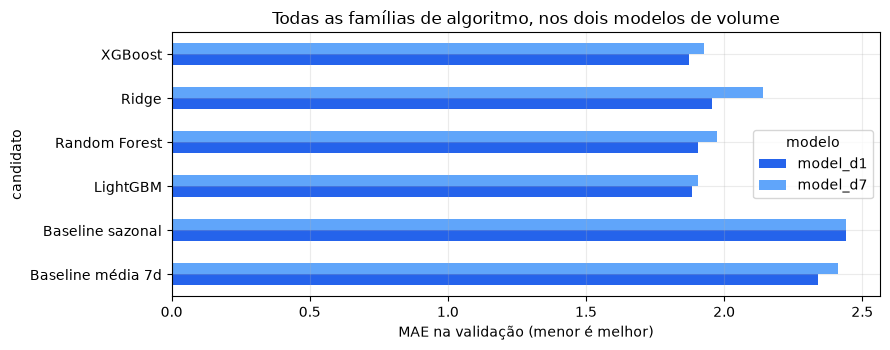

In [4]:
comparacoes = []
for cartao in regressao:
    for linha in cartao['comparacao']:
        comparacoes.append({
            'modelo': cartao['nome'],
            'candidato': linha['candidato'],
            'tipo': linha['tipo'],
            'MAE (validação)': linha['metricas'].get('mae'),
            'vencedor': linha.get('vencedor', False),
        })
pivo = pd.DataFrame(comparacoes).pivot_table(
    index='candidato', columns='modelo', values='MAE (validação)',
)
display(pivo)

fig, eixo = plt.subplots(figsize=(9, 3.6))
pivo.plot(kind='barh', ax=eixo, color=['#2563eb', '#60a5fa'])
eixo.set_xlabel('MAE na validação (menor é melhor)')
eixo.set_title('Todas as famílias de algoritmo, nos dois modelos de volume')
plt.tight_layout(); plt.show()

## Modelos de classificação

In [5]:
classificacao = [c for c in cartoes if c['tipo'] == 'classificacao']
pd.DataFrame([
    {
        'modelo': c['nome'],
        'algoritmo': c['algoritmo'],
        'PR-AUC': c['metricas']['teste']['pr_auc'],
        'ROC-AUC': c['metricas']['teste']['roc_auc'],
        'F1': c['metricas']['teste']['f1'],
        'precisão': c['metricas']['teste']['precision'],
        'recall': c['metricas']['teste']['recall'],
        'taxa-base': c['metricas']['teste']['taxa_base'],
        'lift PR-AUC': round(c['metricas']['teste']['pr_auc'] / c['metricas']['teste']['taxa_base'], 1),
        'Brier': c['metricas']['teste']['brier'],
    }
    for c in classificacao
])

,modelo,algoritmo,PR-AUC,ROC-AUC,F1,precisão,recall,taxa-base,lift PR-AUC,Brier
0,model_pico,RandomForestClassifier (calibrado),0.2240,0.7196,0.2862,0.1802,0.6948,0.1045,2.1,0.0953
1,model_ola,LogisticRegression (calibrado),0.2375,0.9038,0.3077,0.3333,0.2857,0.0129,18.4,0.0118


O **lift de PR-AUC sobre a taxa-base** é a leitura que importa num alvo raro: mede quanto o
modelo concentra os positivos em relação a sortear aleatoriamente.

## Modelos não supervisionados

In [6]:
for cartao in cartoes:
    if cartao['tipo'] in ('anomalia', 'clusterizacao'):
        print(f"\n{cartao['titulo']} — {cartao['algoritmo']}")
        for chave, valor in cartao['metricas'].items():
            if not isinstance(valor, list):
                print(f'    {chave:>24}: {valor}')
        for observacao in cartao.get('observacoes', []):
            print(f'    nota: {observacao}')


Detecção de anomalias — IsolationForest
              dias_avaliados: 16786
                    marcados: 840
             marcados_zscore: 309
         concordancia_zscore: 0.017
            limiar_pontuacao: 0.5575
    nota: Modelo não supervisionado: o dataset não traz rótulo de anomalia, então não há precisão nem recall a reportar — qualquer número desse tipo seria inventado.
    nota: A concordância com o z-score móvel de 21 dias é o que se pode medir: mostra o quanto o modelo reencontra o que a régua univariada já via.

Clusterização de produtos — KMeans
                    silhueta: 0.3212
                 k_escolhido: 2
                    produtos: 20


## O que cada modelo entrega para a operação

In [7]:
pd.DataFrame([
    {'modelo': c['nome'], 'onde aparece na plataforma': destino, 'algoritmo': c['algoritmo']}
    for c, destino in zip(cartoes, [
        'Forecast Engine (D+1), Command Center, Daily Report, Copilot',
        'Forecast Engine (curva de 7 dias e previsão por produto/equipe)',
        'Forecast Engine (probabilidade de pico), Alert Center',
        'Alert Center (risco de OLA por equipe), Forecast Engine (KPI de risco)',
        'Anomaly Detection (dias fora do padrão)',
        'Modelos de ML (grupos de produtos)',
    ])
])

,modelo,onde aparece na plataforma,algoritmo
0,model_d1,"Forecast Engine (D+1), Command Center, Daily R...",XGBRegressor
1,model_d7,Forecast Engine (curva de 7 dias e previsão po...,LGBMRegressor
2,model_pico,"Forecast Engine (probabilidade de pico), Alert...",RandomForestClassifier (calibrado)
3,model_ola,"Alert Center (risco de OLA por equipe), Foreca...",LogisticRegression (calibrado)
4,model_anomalia,Anomaly Detection (dias fora do padrão),IsolationForest
5,model_cluster,Modelos de ML (grupos de produtos),KMeans


In [8]:
indice = registry.indice()
print('Última execução do pipeline:')
for chave, valor in indice.items():
    if chave != 'modelos':
        print(f'  {chave:>16}: {valor}')

Última execução do pipeline:
      executado_em: 2026-09-12T00:02:45+00:00
          segundos: 383.9
     inicio_regime: 2025-01-13
         fim_dados: 2025-12-31
        incidentes: 120670
         entidades: 55
     linhas_matriz: 122507
